# Task 6: Customer Segmentation
**Dataset:** Mall Customer Dataset
**Objective:** Group customers based on behavior (income & spending patterns) using K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')

df = pd.read_csv('mall_customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,62,33,72
1,2,Male,28,24,82
2,3,Male,31,34,24
3,4,Female,19,87,80
4,5,Male,57,56,43


## 1. Exploratory Look

In [2]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.00000
mean,100.500000,43.080000,54.045000,52.25500
std,57.879185,14.698771,27.130857,28.06346
min,1.000000,18.000000,9.000000,8.00000
25%,50.750000,31.750000,26.000000,24.00000
50%,100.500000,42.000000,55.000000,52.00000
75%,150.250000,56.000000,81.000000,81.00000
max,200.000000,69.000000,98.000000,98.00000


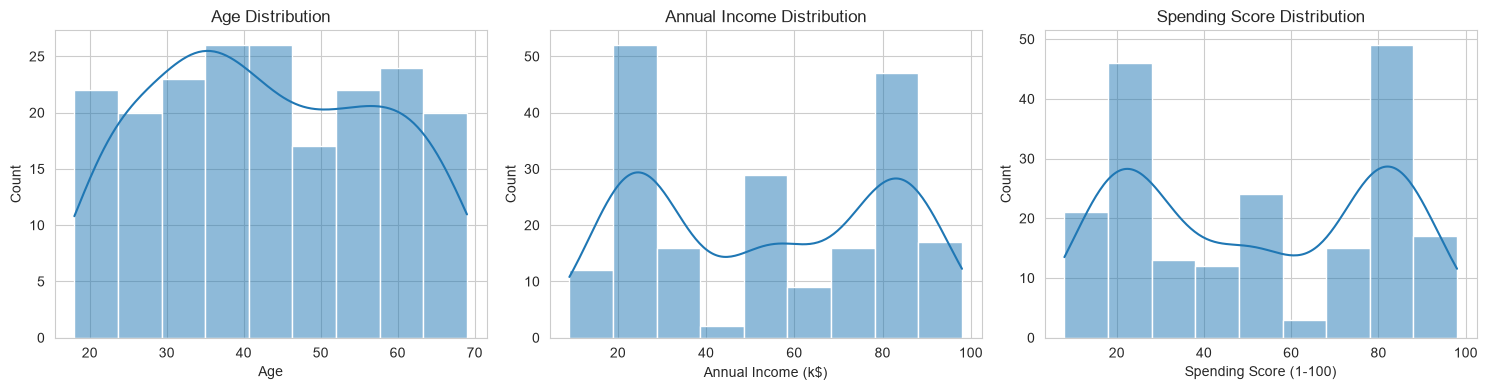

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['Age'], kde=True, ax=axes[0]).set_title('Age Distribution')
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1]).set_title('Annual Income Distribution')
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2]).set_title('Spending Score Distribution')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100)
plt.show()

## 2. Data Preprocessing
We cluster on **Annual Income** and **Spending Score** — the two behavioral variables most relevant to segmentation. Scale them so both features contribute equally.

In [4]:
features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[-0.77763156,  0.70534954],
       [-1.11018961,  1.06257899],
       [-0.74068067, -1.0093518 ],
       [ 1.21771671,  0.9911331 ],
       [ 0.072239  , -0.33061585]])

## 3. Choosing K — Elbow Method


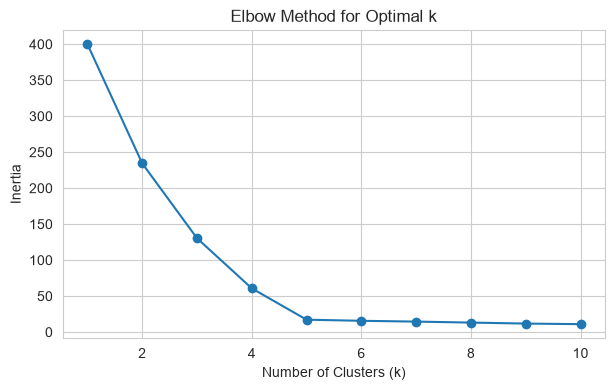

In [5]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.savefig('elbow_method.png', dpi=100)
plt.show()

The elbow flattens out around **k=5**, which also matches the number of natural income/spending groups typically seen in this kind of data.

## 4. Apply K-Means Clustering

In [6]:
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Female,62,33,72,1
1,2,Male,28,24,82,1
2,3,Male,31,34,24,3
3,4,Female,19,87,80,2
4,5,Male,57,56,43,0


## 5. Visualize Clusters

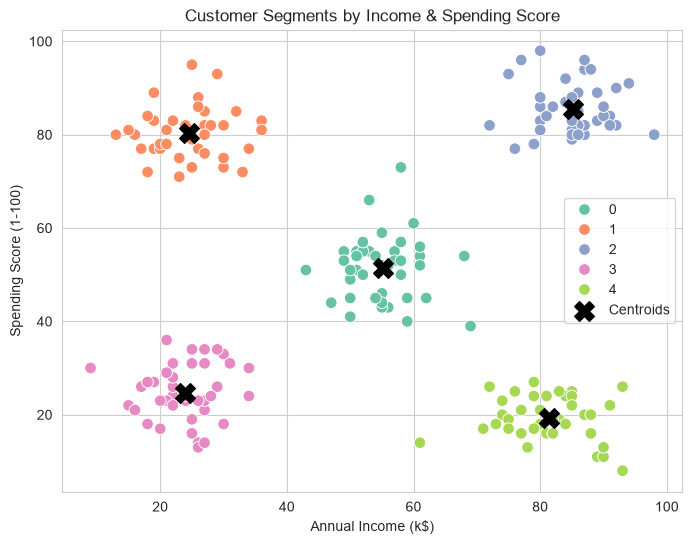

In [7]:
plt.figure(figsize=(8,6))
palette = sns.color_palette('Set2', k_optimal)
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette=palette, s=70
)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X', label='Centroids')
plt.title('Customer Segments by Income & Spending Score')
plt.legend()
plt.savefig('customer_clusters.png', dpi=100)
plt.show()

## 6. Cluster Profiling & Insights

In [8]:
profile = df.groupby('Cluster').agg(
    count=('CustomerID', 'count'),
    avg_age=('Age', 'mean'),
    avg_income=('Annual Income (k$)', 'mean'),
    avg_spending=('Spending Score (1-100)', 'mean')
).round(1)
profile

,count,avg_age,avg_income,avg_spending
Cluster,,,,
0,40,42.5,55.1,51.4
1,40,44.4,24.6,80.4
2,40,39.7,85.2,85.5
3,40,42.5,23.9,24.6
4,40,46.2,81.4,19.3


In [9]:
df.to_csv('mall_customers_segmented.csv', index=False)
print("Saved -> mall_customers_segmented.csv")

Saved -> mall_customers_segmented.csv
